<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Metodos-computacionales/Tarea_4_MC_JM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sympy import *
%matplotlib inline

## **Punto 1.** Comparacion del Error Promedio del metodo derivada Forward y Central

In [ ]:
def Err_prom_deriv(Δ):

  list_E_PROM_DF = []  # listas para errores promedio para cada Δi
  list_E_PROM_DC = []

  for n in tqdm(range(len(Δ))): # iteracion para cada paso Δ del array
    x = np.arange(0, 2*np.pi + Δ[n], Δ[n]) # dominio discreto
    def f(x):  return np.cos(x)            # funcion a evaluar
    def df(x): return -np.sin(x)           # y su derivada

    df_f = np.zeros(len(x))                # array deriv forward
    df_c = np.zeros(len(x))                # array deriv central

    for i in range(len(x)):
      df_f[i] = ( f( x[i]+Δ[n] )- f(x[i]) ) /Δ[n]            # deriv forward
      df_c[i] = ( f( x[i]+Δ[n] )- f( x[i]-Δ[n] ) ) /(2*Δ[n]) # deriv central

    err_df_f = np.abs(df_f - df(x))        # array errores forw y central
    err_df_c = np.abs(df_c - df(x))

    list_E_PROM_DF.append( sum(err_df_f)/len(err_df_f)) # error promedio x cada Δi
    list_E_PROM_DC.append( sum(err_df_c)/len(err_df_c))

  return list_E_PROM_DF, list_E_PROM_DC     # listas errores prom asociados a cada Δi

In [ ]:
# lista de Δ
Δ_list=[] ; Δo = 1e-5

for i in range(6):
  Δ_list.append(Δo); Δo = Δo*1e+1
Δ = np.array(Δ_list)

print('Lista de deltas:',Δ)

Lista de deltas: [1.e-05 1.e-04 1.e-03 1.e-02 1.e-01 1.e+00]


In [ ]:
eprom_DF, eprom_DC = Err_prom_deriv(Δ)

100%|██████████| 6/6 [00:16<00:00,  2.74s/it]


 Δ=1e-05; diferencia error prom forward-central: 0.000003
 Δ=0.0001; diferencia error prom forward-central: 0.000032
 Δ=0.001; diferencia error prom forward-central: 0.000318
 Δ=0.01; diferencia error prom forward-central: 0.003177
 Δ=0.1; diferencia error prom forward-central: 0.031116
 Δ=1.0; diferencia error prom forward-central: 0.232282


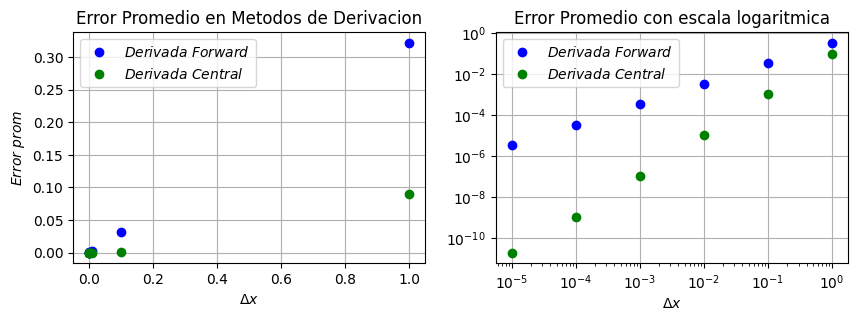

In [ ]:
# Grafica errores en derivada
fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(10,3))
axes[0].set_title('Error Promedio en Metodos de Derivacion')
axes[0].plot(Δ_list, eprom_DF, 'bo', label='$Derivada$ $Forward$')
axes[0].plot(Δ_list, eprom_DC, 'go', label='$Derivada$ $Central$')
axes[0].set_ylabel('$Error$ $prom$')
axes[0].set_xlabel('Δ$x$')
axes[0].legend()
axes[0].grid()
# Grafica errores en derivada: ejes Logaritmicos
axes[1].set_title('Error Promedio con escala logaritmica')
axes[1].plot(Δ_list, eprom_DF, 'bo', label='$Derivada$ $Forward$')
axes[1].plot(Δ_list, eprom_DC, 'go', label='$Derivada$ $Central$')
axes[1].set_xlabel('Δ$x$')
axes[1].semilogy()
axes[1].semilogx()
axes[1].legend()
axes[1].grid()

for i in range(len(Δ_list)):
  print(f' Δ={Δ_list[i]}; diferencia error prom forward-central: {np.abs(eprom_DF[i]-eprom_DC[i]):1f}')

#### **Análisis:**

Se observa que el error promedio de la **Derivada Central** para los deltas del conjunto: $ \Delta_{x} = \left \{10^{-5},10^{-4},10^{-3},..,10^{0} \right \}$ siempre es menor que el error promedio de la **Derivada Forward**. Reafirmando lo visto en clase; donde la derivada central a pesar de requerir información de la función en los $2$ puntos consecutivos al punto que se desea calcular la derivada (atrás y adelante del punto) es más precisa que la derivada forward, la cual requiere información del mismo punto donde se realiza la derivada y su consecutivo siguiente.

<p align="justify">
También se observa que mientras el tamaño del paso $\Delta_{x}$ sea mayor, el error promedio en ambos métodos también será mayor, y la diferencia entre ambos tambien será más significativa. Se evidencia que la tasa de crecimiento que tiende a seguir el error de la derivada forward es mayor que la central. Note que ambos errores se pueden ajustar a funciones que tienden a 0 cuando $\Delta_{x}$ tiende a 0; por lo que los errores promedio para $\Delta_{x}$ muy pequeños tienden a diferir muy poco; por ejemplo para $\Delta_{x}=10^{-5}$ el error promedio de ambas difiere en apenas $10^{-6}$ ordenes de magnitud. </p>


<br>

## **Punto 2.** Calculo de Integrales: Metodo del _Trapecio_ y _Simpsion_

Utilizando las reglas compuestas obtener errores absolutos del orden $10^{-3}$





In [ ]:
def Ar_trap(f,a,b):   # metodo trapecio
    return 0.5*(b-a)*(f(a)+f(b))

def Ar_simp(f,a,b):   # metodo simpson
    xn = np.linspace(a,b,3) # intervalo discreto
    h = xn[1]-xn[0]   # paso
    return (h/3.)*(f(xn[0])+4*f(xn[1])+f(xn[2]))

def Ar(F,a,b):       # area integral (F) real
    return F(b)-F(a)

# adicional --------------------------------------
def interpolacion_Lagrange(x_int,xn,yn):
    n=len(xn)-1
    def L(x,n,i):
        prod=1.
        for m in range(0,n+1):
            if m != i:
                prod*= (x-xn[m])/(xn[i]-xn[m])
        return prod
    suma=0
    for i in range(0,n+1):
        suma+=yn[i]*L(x_int,n,i)
    return suma
def Quadrature(N,f,a,b,  xmin,xmax):
    dx=0.01
    x = np.arange(xmin,xmax,dx)
    xf = np.arange(a,b+dx,dx)
    xn = np.linspace(a,b,N)
    yn = f(xn)
    y = np.zeros(len(xf))
    for i in range(len(xf)):
        y[i]=interpolacion_Lagrange(xf[i],xn,yn)
    plt.plot(x,f(x),color='black',zorder=1)
    plt.plot(xn,yn,'o',color='red',zorder=2)
    plt.plot(xf,y,color='blue',zorder=3)
    plt.vlines(a,0,f(a),linestyles='dashed')
    plt.vlines(b,0,f(b),linestyles='dashed')
    plt.hlines(0,xmin,xmax,linestyles='dashed')
    plt.fill_between(xf,y,color='green',alpha=0.5)
    plt.grid(True)

In [ ]:
# Funciones a integrar numericamente:
x = Symbol('x')

fun1 = exp(-x)                # funcion 1 simbolica
Fun1 = integrate(fun1,x)      # integral simbolica
f1 = lambdify(x,fun1,"numpy") # pasando simbolico a numerico
F1 = lambdify(x,Fun1,"numpy")

fun2 = sin(x)**2              # funcion 2 simbolica
Fun2 = integrate(fun2,x)      # integral simbolica
f2 = lambdify(x,fun2,"numpy") # pasando simbolico a numerico
F2 = lambdify(x,Fun2,"numpy")

$$ \int_{0}^{1}e^{-x}dx $$

Area Trapecio compuesto: 0.6379627167307008
Area Simpson compuesto: 0.6323336800036626
Area real: 0.6321205588285577

Error absoluto Trapecio: 0.0058421579021431524
Error absoluto Simpson: 0.00021312117510496886 



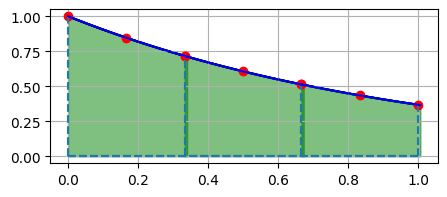

In [ ]:
N1 = 3 ; Ni_t = 3; Ni_s = 1 # orden de cuadratura ; num rectangulos(trape,simp)
a1 = 0 ; b1 = 1     # intervalo de integracion
xmin=0 ; xmax=1     # intervalo grafica cuadratura
hi = (b1-a1)/Ni_t   # tamaño paso

ab = np.linspace(a1,b1,Ni_t+1) ; ab_s = np.linspace(a1,b1,Ni_s+1) # divisiones
Ar_trap_comp = 0; Ar_simp_comp = 0 # inicializacion variables

plt.figure(figsize=(5,2))
for i in range(0,Ni_t):
    Quadrature(N1,f1,ab[i],ab[i+1],  xmin,xmax)
    Ar_trap_comp += Ar_trap(f1,ab[i],ab[i+1])

for i in range(0,Ni_s):
    Ar_simp_comp += Ar_simp(f1,ab_s[i],ab_s[i+1])

error_t = np.abs(Ar(F1,a1,b1)- Ar_trap_comp)
error_s = np.abs(Ar(F1,a1,b1)- Ar_simp_comp)
print('Area Trapecio compuesto:', Ar_trap_comp)
print('Area Simpson compuesto:', Ar_simp_comp)
print('Area real:', Ar(F1,a1,b1))
print('\nError absoluto Trapecio:', error_t) # Error absoluto del orden 10^-3
print('Error absoluto Simpson:', error_s,'\n') # Error absoluto del orden 10^-4

$$ \int_{0}^{2\pi}sin^{2}(x)dx $$

Area Trapecio compuesto: 3.1415926535897922
Area Simpson compuesto: 3.141592653589793
Area real: 3.141592653589793

Error absoluto Trapecio: 8.881784197001252e-16
Error absoluto Simpson: 0.0 



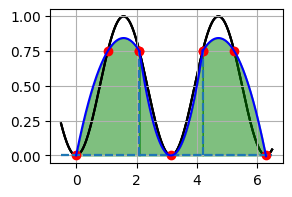

In [ ]:
N2 = 3 ; Ni_t = 3; Ni_s = 3   # orden de cuadratura ; num rectangulos
a2 = 0 ; b2 = 2*np.pi  # intervalo
xmin=-0.5 ; xmax=6.5 # intervalo
hi = (b2-a2)/Ni_t    # tamaño paso
ab = np.linspace(a2,b2,Ni_t+1) ; ab_s = np.linspace(a2,b2,Ni_s+1) # divisiones
Ar_trap_comp2 = 0 ; Ar_simp_comp2 = 0 # inicializacion variables


plt.figure(figsize=(3,2))
for i in range(0,Ni_t):
    Ar_trap_comp2 += Ar_trap(f2,ab[i],ab[i+1])

for i in range(0,Ni_s):
    Ar_simp_comp2 += Ar_simp(f2,ab_s[i],ab_s[i+1])
    Quadrature(N2,f2,ab_s[i],ab_s[i+1],  xmin,xmax)

error_t2 = np.abs(Ar(F2,a2,b2)- Ar_trap_comp2)
error_s2 = np.abs(Ar(F2,a2,b2)- Ar_simp_comp2)
print('Area Trapecio compuesto:', Ar_trap_comp2)
print('Area Simpson compuesto:', Ar_simp_comp2)
print('Area real:', Ar(F2,a2,b2))
print('\nError absoluto Trapecio:', error_t2) # Error absoluto
print('Error absoluto Simpson:', error_s2,'\n') # Error absoluto


## **Punto 3.** Calculo de Integrales: Comparacion Metodo del _Trapecio_ y _Simpsion_

$$ arctan(x)= \int_{0}^{x}\frac{1}{1+y^{2}}dy$$

In [ ]:
def fun(x): # funcion a integrar
  return 1/(x**2+1)

# modificacion para este caso particular:
def Ar_simp_mod(f,a,b):   # metodo simpson
    xn = [a,b/2,b]    # (a=0, b/2=x/2 , b=x)
    h = xn[1]-xn[0]   # paso h=x/2
    return (h/3.)*(f(xn[0])+4*f(xn[1])+f(xn[2]))

In [ ]:
# integral real
I_R = atan(x)   # integral simbolica
i_r = lambdify(x,I_R,"numpy")

In [ ]:
# metodo trapecio
I_T = Ar_trap(fun,0,x)
i_t = lambdify(x,I_T,"numpy")

print('Integral por metodo Trapecio:')
I_T

Integral por metodo Trapecio:


0.5*x*(1.0 + 1/(x**2 + 1))

In [ ]:
# metodo simpson
I_S = Ar_simp_mod(fun,0,x)
i_s = lambdify(x,I_S,"numpy")

print('Integral por metodo Simpson:')
I_S

Integral por metodo Simpson:


0.166666666666667*x*(1.0 + 1/(x**2 + 1) + 4/(x**2/4 + 1))

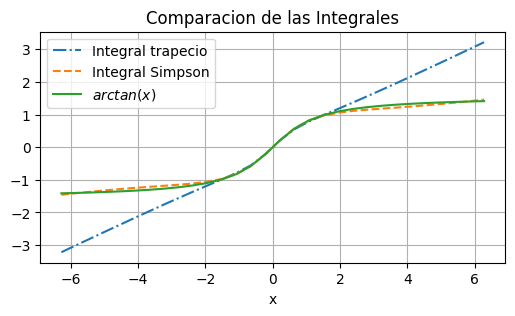

In [ ]:
# Comparacion de las tres integrales:
xc = np.linspace(-2*np.pi,2*np.pi,30) # dominio de visualizacion

plt.figure(figsize=(6,3))
plt.title('Comparacion de las Integrales')
plt.plot(xc,i_t(xc),'-.',label='Integral trapecio')
plt.plot(xc,i_s(xc),'--',label='Integral Simpson')
plt.plot(xc,i_r(xc),label='$arctan(x)$')
plt.xlabel('x')
plt.legend()
plt.grid()
plt.show()

## **Punto 4.** Deduccion analitica del metodo de Simpson:

$$\int_a^b f(x) dx \approx \int_{x_0}^{x_2}  P_2(x)dx$$
<br>

Con el polinomio:
<br>
$$P_2(x)=f(x_0) \frac{x-x_1}{x_0-x_1}\frac{x-x_2}{x_0-x_2} + f(x_1) \frac{x-x_0}{x_1-x_0}\frac{x-x_2}{x_1-x_2} + f(x_2) \frac{x-x_0}{x_2-x_0}\frac{x-x_1}{x_2-x_1}$$
<br>

Se tiene: $x_{i+1}=x_i+h \;; \forall i$, y con la sustitucion:

> $\left\{\begin{matrix}
x-x_{0}=ht \;\rightarrow \; dx=hdt\\
x-x_{1}=h(t-1)\\
x-x_{2}=h(t-2)  
\end{matrix}\right.$
<br>

$$P_{2}(x)= f(x_0) \frac{h^{2}(t-1)(t-2)}{2h^{2}} + f(x_1) \frac{h^{2}t(t-2)}{-h^{2}} + f(x_2) \frac{h^{2}t(t-1)}{2h^{2}}$$

$$=f(x_0) (t^{2}-3t+2) - f(x_1) (t^{2}-2t) + f(x_2) (t^{2}-t) $$
<br>

Finalmente evaluando el polinomio en la integral se llega a la expresión de la regla de Simpson: <br>

$$ \int_{x=x_0}^{x=x_2}P_2(x)dx=\int_{t=0}^{t=2} \left[  f(x_0) (t^{2}-3t+2) - f(x_1) (t^{2}-2t) + f(x_2) (t^{2}-t)   \right] h*dt $$

$$ =h\left[ \frac{f(x_0)}{2}(\frac{t^{3}}{3}-\frac{3t^{2}}{2}+2t)- f(x_1)(\frac{t^{3}}{3}-t^{2}) + \frac{f(x_2)}{2}(\frac{t^{3}}{3}-\frac{t^{2}}{2})
\right] ^{t=2}_{t=0}$$

$$ = h \left[  \frac{f(x_0)}{2}\frac{2}{3}+ f(x_1)\frac{4}{3} +
\frac{f(x_2)}{3}  \right]$$

$$ \int_a^b f(x) dx=\frac{h}{3} (f(x_0)+4f(x_1)+f(x_2))$$

In [ ]:
#Tarea 4 90/100

#1. Función dx 25/25
#Forward  10/10
#Central  10/10
#Gráfico   5/5

#2. Integrales 25/25
#a) 12/12
#b) 13/13

#3. Arctan 15/25
#Está mal implementado el simpy y las funciones que utilizas
#El trapecio no debería distar tanto en los extremos.

#4. Simpson 25/25
